## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import json
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.utils import to_categorical

## Load and Prepare the Dataset

In [2]:
df1 = pd.read_csv("kinyarwanda_hard_texts.csv")
df2 = pd.read_csv("realistic_kinyarwanda_hate_sarcasm_normal.csv")
df = pd.concat([df1, df2], ignore_index=True)
df.head()

# Clean labels
df["label"] = df["label"].str.strip().str.lower()
df["label"] = df["label"].replace({"sarcasm/joke": "sarcasm"})
df.head()


,text,label
0,"Noneho Ndumva Ubwo Hahaha, ntacyo, murakoze cy...",sarcasm
1,Hmmm Ngo Ngo Ngo Abanzi b’igihugu bakwiye guku...,hate
2,Noneho Murakoze Ngo Ngo Ndumva Iyo myitwarire ...,hate
3,"Murakoze Ndumva Hahaha, ntacyo, murakoze cyane...",sarcasm
4,"Hmmm Ubwo Hahaha, ntacyo, murakoze cyane pe, n...",sarcasm


In [3]:
df.shape

(18073, 2)

In [4]:
# class count
count_class_normal, count_class_sarcasm, count_class_hate = df.label.value_counts()
count_class_normal, count_class_sarcasm, count_class_hate

(7817, 5140, 5116)

In [5]:
df_class_hate = df[df['label']=="hate"]
df_class_normal = df[df['label']== "normal"]
df_class_sarcasm = df[df['label']== "sarcasm"]

In [6]:
df_class_sarcasm_over = df_class_sarcasm.sample(count_class_normal, replace=True)
df_class_hate_over = df_class_hate.sample(count_class_normal, replace=True)

df_test_over = pd.concat([df_class_hate_over,df_class_sarcasm_over,df_class_normal], axis=0)

print(df_test_over.label.value_counts())

label
hate       7817
sarcasm    7817
normal     7817
Name: count, dtype: int64


### label distribution

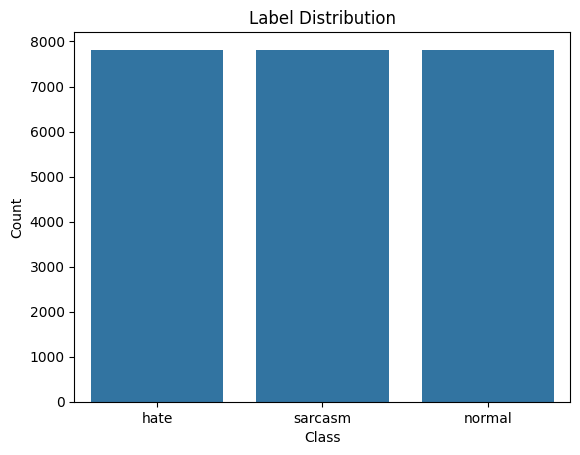

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_test_over, x="label", order=df_test_over["label"].value_counts().index)
plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### label encoding

In [8]:
maps = {'hate':0, 'normal':1, 'sarcasm':2}
df_test_over['label_id'] = df_test_over.label.map(maps)

In [9]:
df_test_over

,text,label,label_id
18024,bro Abahutu Urupfu,hate,0
14379,Inzangano Ntacyo mumaze haha Muraho Urupf...,hate,0
9995,Lol Mbega Abanzi Ok Inda nini Kandi Ibinyoma H...,hate,0
4608,Urupfu Basi Ngo Noneho Noneho Inda nini Basi I...,hate,0
6711,Kandi Ntacyo mumaze Urupfu Hmmm Cyane Ok,hate,0
...,...,...,...
18053,Ibyiza byinshi lol Imirimo sha Ibyiza byinshi ...,normal,1
18059,sha Imirimo Ibyiza byinshi lol Ikirere Umutuzo,normal,1
18062,Ibyiza byinshi smh Umutuzo Muraho lol Ikirere,normal,1
18067,Ubuzima Turashimira Ubuzima Amahoro sha kbs Am...,normal,1


In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    return text.strip()

df_test_over["text"] = df_test_over["text"].apply(clean_text)
df_test_over.head()

,text,label,label_id
18024,bro abahutu urupfu,hate,0
14379,inzangano ntacyo mumaze haha muraho urupfu ese...,hate,0
9995,lol mbega abanzi ok inda nini kandi ibinyoma h...,hate,0
4608,urupfu basi ngo noneho noneho inda nini basi i...,hate,0
6711,kandi ntacyo mumaze urupfu hmm cyane ok,hate,0


In [11]:
# 1. Tokenize & pad sequences
texts = df_test_over['text'].tolist()
labels = df_test_over['label_id'].values

# Parameters
max_vocab_size = 10000
max_seq_length = 50  # adjust based on sentence length distribution
embedding_dim = 100
num_classes = len(np.unique(labels))

tokenizer = Tokenizer(num_words=max_vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_seq_length, padding='post', truncating='post')

In [12]:
tokenizer_json = tokenizer.to_json()
with open("kinya_tokenizer.json", "w", encoding="utf-8") as f:
    f.write(tokenizer_json)

In [13]:
labels_cat = to_categorical(labels, num_classes=num_classes)

X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels_cat, test_size=0.2, random_state=42, stratify=labels)

In [14]:
cnn = Sequential([
        Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, input_length=max_seq_length),
        Conv1D(filters=128, kernel_size=5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

c:\Users\Hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [15]:
history = cnn.fit(X_train, y_train,
                epochs=10,
                batch_size=64,
                validation_split=0.1,
                verbose=1
)

Epoch 1/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 165s 500ms/step - accuracy: 0.9404 - loss: 0.1959 - val_accuracy: 0.9893 - val_loss: 0.0347
Epoch 2/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 133s 503ms/step - accuracy: 0.9861 - loss: 0.0441 - val_accuracy: 0.9888 - val_loss: 0.0262
Epoch 3/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 115s 391ms/step - accuracy: 0.9903 - loss: 0.0298 - val_accuracy: 0.9872 - val_loss: 0.0297
Epoch 4/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 83s 312ms/step - accuracy: 0.9931 - loss: 0.0228 - val_accuracy: 0.9893 - val_loss: 0.0243
Epoch 5/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 111s 419ms/step - accuracy: 0.9950 - loss: 0.0157 - val_accuracy: 0.9893 - val_loss: 0.0241
Epoch 6/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 121s 337ms/step - accuracy: 0.9967 - loss: 0.0112 - val_accuracy: 0.9931 - val_loss: 0.0213
Epoch 7/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 127s 280ms/step - accuracy: 0.9966 - loss: 0.0095 - val_accuracy: 0.9920 - val_loss: 0.0219
Epoch 8/10
264/264 ━━━━━━━━━━━━━━━━━━━━ 95s 328ms/step - accuracy: 0.9976 - l

In [16]:
# Evaluate
loss, accuracy = cnn.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

147/147 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.9906 - loss: 0.0450
Test accuracy: 0.9906


In [17]:
samples = [
    "Umwana na se",  # should be normal
    "Abatutsi baracyariho",  # hate
    "Uwanga umwana ntakabone ijuru",  # normal
    "U Rwanda n igihugu kiza",  # normal
    "Inyenzi ninde wakubeshye ko zashize mu Rwanda",  # ambiguous
    "Sha murabeshya cyane 😂 ngo mwatsinze? Hmmm",
    "Abahutu ntacyo bamaze, rwose.",
    "Muraho neza, ndabashimiye ku bufasha bwanyu 🙏",
    "Ese wowe urumva nkwiye kwemera ibyo? Sha uransetsa kabisa",
    "Iyo myitwarire y’abatutsi ntitwakwihanganira pe!",
    "Turashimira Imana ko turi amahoro n’ubumwe",
    "Ngo uri umuyobozi? Hahahaha! Urimo kudusetsa sha.",
    "Inkotanyi nizindi nyenzi ziri kwica igihugu cyacu",
    "Imana ihe umugisha u Rwanda rwacu",
    "Kabisa uri umuntu mwiza, courage kuri byose",
    "Ngo mukunda abaturage, Ariko se ibyo murimo ni iki?",
    "Sha nta kindi nari ntegereje ku batutsi!",
]

In [18]:
def dl_predict(model, texts):
    clean_texts = [clean_text(t) for t in texts]
    seqs = tokenizer.texts_to_sequences(clean_texts)
    padded = pad_sequences(seqs, maxlen=max_seq_length, padding='post', truncating='post')
    preds = model.predict(padded, verbose=0)
    classes = np.argmax(preds, axis=1)
    return [label_map[c] for c in classes]

# Label map from your code (adjust if needed)
label_map = {0: 'hate', 1: 'normal', 2: 'sarcasm'}

# Predict with CNN (model2)
cnn_preds = dl_predict(cnn, samples)
print("\nCNN Predictions:")
for text, pred in zip(samples, cnn_preds):
    print(f"{text} -> {pred}")


CNN Predictions:
Umwana na se -> sarcasm
Abatutsi baracyariho -> hate
Uwanga umwana ntakabone ijuru -> hate
U Rwanda n igihugu kiza -> hate
Inyenzi ninde wakubeshye ko zashize mu Rwanda -> normal
Sha murabeshya cyane 😂 ngo mwatsinze? Hmmm -> normal
Abahutu ntacyo bamaze, rwose. -> hate
Muraho neza, ndabashimiye ku bufasha bwanyu 🙏 -> normal
Ese wowe urumva nkwiye kwemera ibyo? Sha uransetsa kabisa -> sarcasm
Iyo myitwarire y’abatutsi ntitwakwihanganira pe! -> sarcasm
Turashimira Imana ko turi amahoro n’ubumwe -> normal
Ngo uri umuyobozi? Hahahaha! Urimo kudusetsa sha. -> normal
Inkotanyi nizindi nyenzi ziri kwica igihugu cyacu -> hate
Imana ihe umugisha u Rwanda rwacu -> normal
Kabisa uri umuntu mwiza, courage kuri byose -> normal
Ngo mukunda abaturage, Ariko se ibyo murimo ni iki? -> sarcasm
Sha nta kindi nari ntegereje ku batutsi! -> normal


In [19]:
from sklearn.metrics import classification_report
y_prred = np.argmax(cnn.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true, y_prred, target_names=['hate','normal','sarcasm']))

147/147 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step
              precision    recall  f1-score   support

        hate       0.99      0.99      0.99      1563
      normal       0.99      0.99      0.99      1564
     sarcasm       0.99      0.99      0.99      1564

    accuracy                           0.99      4691
   macro avg       0.99      0.99      0.99      4691
weighted avg       0.99      0.99      0.99      4691



In [20]:
cnn.save('kinya.keras')

## Train-Test Split + HuggingFace Dataset Conversion

In [21]:
# from sklearn.model_selection import train_test_split

# train_df, test_df = train_test_split(df, stratify=df["label_id"], test_size=0.2, random_state=42)

# train_ds = Dataset.from_pandas(train_df[["text", "label_id"]])
# test_ds = Dataset.from_pandas(test_df[["text", "label_id"]])


### word cloud visuals

In [22]:
# from wordcloud import WordCloud
# import matplotlib.pyplot as plt

# for label in df["label"].unique():
#     text = " ".join(df[df["label"] == label]["text"])
#     wc = WordCloud(width=800, height=400, background_color="white").generate(text)

#     plt.figure(figsize=(10, 5))
#     plt.imshow(wc, interpolation='bilinear')
#     plt.title(f"WordCloud for '{label}'")
#     plt.axis("off")
#     plt.show()


## Load Tokenizer & Tokenize Dataset

In [23]:
# model_name = "Davlan/afro-xlmr-mini"
# tokenizer = AutoTokenizer.from_pretrained(model_name)

# def tokenize_batch(batch):
#     return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

# train_ds = train_ds.map(tokenize_batch, batched=True)
# test_ds = test_ds.map(tokenize_batch, batched=True)


## Load Model

In [24]:
# model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

## Define Metrics

In [25]:
# accuracy = evaluate.load("accuracy")
# f1 = evaluate.load("f1")

# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     predictions = np.argmax(logits, axis=-1)
#     return {
#         "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
#         "f1_macro": f1.compute(predictions=predictions, references=labels, average="macro")["f1"]
#     }


## Set Training Arguments

In [26]:
# training_args = TrainingArguments(
#     output_dir="afro-xlmr-mini-output",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     num_train_epochs=4,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=32,
#     learning_rate=2e-5,
#     weight_decay=0.01,
#     load_best_model_at_end=True,
#     metric_for_best_model="f1_macro",
#     save_total_limit=2,
#     fp16=torch.cuda.is_available()
# )


In [27]:
# # Rename label column to what Trainer expects
# train_ds = train_ds.rename_column("label_id", "labels")
# test_ds = test_ds.rename_column("label_id", "labels")


## Create Trainer and Train

In [28]:
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_ds,
#     eval_dataset=test_ds,
#     tokenizer=tokenizer,
#     compute_metrics=compute_metrics
# )

# trainer.train()


## Evaluate Model

In [29]:
# metrics = trainer.evaluate()
# metrics

### Confusion Matrix

In [30]:
# # from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# # # Get true labels and predictions
# # true_labels = test_df["label_id"].values
# # test_texts = test_df["text"].tolist()

# # pred_labels = []
# # for text in test_texts:
# #     inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
# #     # Move input tensors to the same device as the model
# #     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# #     inputs = {k: v.to(device) for k, v in inputs.items()}
# #     model.to(device)  # Ensure model is on the correct device

# #     outputs = model(**inputs)
# #     pred = torch.argmax(outputs.logits, dim=1).item()
# #     pred_labels.append(pred)

# # # Plot confusion matrix
# # cm = confusion_matrix(true_labels, pred_labels)
# # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
# # disp.plot(cmap="Blues", xticks_rotation=45)
# # plt.title("Confusion Matrix")
# # plt.show()

# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import torch
# import matplotlib.pyplot as plt

# # Set device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)

# # Get true labels and texts
# true_labels = test_df["label_id"].values
# test_texts = test_df["text"].tolist()

# # Run model predictions
# pred_labels = []
# model.eval()  # Set model to eval mode

# with torch.no_grad():
#     for text in test_texts:
#         inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
#         inputs = {k: v.to(device) for k, v in inputs.items()}

#         outputs = model(**inputs)
#         pred = torch.argmax(outputs.logits, dim=1).item()
#         pred_labels.append(pred)

# # Generate confusion matrix
# cm = confusion_matrix(true_labels, pred_labels)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

# # Plot
# fig, ax = plt.subplots(figsize=(6, 6))
# disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)
# plt.title("Confusion Matrix")
# plt.tight_layout()
# plt.show()

### Classification Report

In [31]:
# from sklearn.metrics import classification_report
# print(classification_report(true_labels, pred_labels, target_names=label_encoder.classes_))


## Inference Examples

In [32]:
# def predict_label(text):
#     inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
#     # Move input tensors to the same device as the model
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     inputs = {k: v.to(device) for k, v in inputs.items()}

#     model.to(device)  # Ensure model is on the correct device

#     outputs = model(**inputs)
#     predicted_class = torch.argmax(outputs.logits, dim=1).item()
#     return label_encoder.inverse_transform([predicted_class])[0]

# # Test examples
# examples = [
#     "Umwana na se",  # should be normal
#     "Abatutsi baracyariho",  # hate
#     "Uwanga umwana ntakabone ijuru",  # normal
#     "U Rwanda n igihugu kiza",  # normal
#     "Inyenzi ninde wakubeshye ko zashize mu Rwanda",  # ambiguous
# ]

# for ex in examples:
#     print(f"{ex} → {predict_label(ex)}")

## more examples (adding emojis)

In [33]:
# examples = [
#     "Sha murabeshya cyane 😂 ngo mwatsinze? Hmmm",
#     "Abahutu ntacyo bamaze, rwose.",
#     "Muraho neza, ndabashimiye ku bufasha bwanyu 🙏",
#     "Ese wowe urumva nkwiye kwemera ibyo? Sha uransetsa kabisa",
#     "Iyo myitwarire y’abatutsi ntitwakwihanganira pe!",
#     "Turashimira Imana ko turi amahoro n’ubumwe",
#     "Ngo uri umuyobozi? Hahahaha! Urimo kudusetsa sha.",
#     "Inkotanyi nizindi nyenzi ziri kwica igihugu cyacu",
#     "Imana ihe umugisha u Rwanda rwacu",
#     "Kabisa uri umuntu mwiza, courage kuri byose",
#     "Ngo mukunda abaturage, Ariko se ibyo murimo ni iki?",
#     "Sha nta kindi nari ntegereje ku batutsi!",
# ]

# for ex in examples:
#     print(f"{ex} → {predict_label(ex)}")


## Save Model & Label Encoder

In [34]:
# model.save_pretrained("kinyarwanda-hatespeech-model")
# tokenizer.save_pretrained("kinyarwanda-hatespeech-model")
# import joblib
# joblib.dump(label_encoder, "label_encoder.pkl")


In [35]:
# from google.colab import files
# import shutil

# # Zip the model folder
# shutil.make_archive("kinyarwanda-hatespeech-model", 'zip', "kinyarwanda-hatespeech-model")

# # Download it
# files.download("kinyarwanda-hatespeech-model.zip")